In [18]:
# 이미지 객체 감지 후, 해당 객체에 대한 설명을 생성하는 코드 예시
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import datetime
import urllib.parse
import csv
from collections import Counter

# 객체 설명과 링크 제공
object_info = {
    "person": {
        "description": "이 객체는 사람이 감지된 경우입니다. 사람 감지는 보안 감시, 출입 관리 시스템 등에 매우 유용합니다. 또한 얼굴 인식, 행동 분석 등 다양한 분야에 적용됩니다.",
        "use_case": "사람 감지는 보안 시스템에서 출입 관리, 비상 상황에서의 대처, 헬스케어 분야에서 노인 및 환자의 상태 모니터링에 사용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("사람"))
    },
    "car": {
        "description": "이 객체는 자동차가 감지된 경우입니다. 자동차 감지는 교통 흐름 분석, 불법 주차 감시, 사고 예방 등 다양한 분야에 활용됩니다.",
        "use_case": "자동차 감지는 자율 주행 시스템, 스마트 교통 시스템, 교차로 모니터링 등에 활용되며, 도시 계획 및 교통 관리에도 중요한 역할을 합니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("자동차"))
    },
    "truck": {
        "description": "이 객체는 트럭이 감지된 경우입니다. 트럭 감지는 물류 창고 관리, 도로 교통 모니터링, 고속도로에서의 추적 등에 활용됩니다.",
        "use_case": "트럭 감지는 물류 효율화, 고속도로 사고 예방, 교통량 분석 등에 사용되며, 스마트 물류 및 재난 관리 시스템에도 중요합니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("트럭"))
    },
    "motorcycle": {
        "description": "이 객체는 오토바이가 감지된 경우입니다. 오토바이 감지는 교통 사고 예방 시스템, 도로에서의 차량 추적 등에 사용됩니다.",
        "use_case": "오토바이 감지는 도로 교통 사고 예방, 긴급 상황 대응, 스마트 교통 시스템 등에 사용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("오토바이"))
    },
    "dog": {
        "description": "이 객체는 강아지가 감지된 경우입니다. 강아지 감지는 반려동물 보호, 유기 동물 탐지 및 동물원 관리 등에서 중요합니다.",
        "use_case": "강아지 감지는 동물 보호 시스템, 유기 동물 탐지 시스템 및 스마트 펫 모니터링 시스템에 사용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("강아지"))
    },
    "cat": {
        "description": "이 객체는 고양이가 감지된 경우입니다. 고양이 감지는 스마트 펫 모니터링 시스템과 연계되어 유용하게 사용됩니다.",
        "use_case": "고양이 감지는 반려동물 모니터링 시스템, 동물원 관리 및 스마트 홈 시스템에 활용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("고양이"))
    },
    "bus": {
        "description": "이 객체는 버스가 감지된 경우입니다. 버스 감지는 대중교통 분석, 버스 전용차로 감시 및 혼잡도 모니터링 등에 활용됩니다.",
        "use_case": "버스 감지는 스마트 시티 교통 시스템, 버스 정류장 혼잡도 분석 및 통근 시간 최적화에 사용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("버스"))
    },
    "bird": {
        "description": "이 객체는 새가 감지된 경우입니다. 새 감지는 자연 생태 모니터링, 조류 충돌 방지 시스템 등에 활용됩니다.",
        "use_case": "새 감지는 공항의 조류 충돌 방지 시스템, 야생 동물 보호 구역의 생태계 분석, 스마트 환경 감시 시스템에 활용됩니다.",
        "link": "https://ko.wikipedia.org/wiki/{}".format(urllib.parse.quote("새"))
    }
}





0: 448x640 2 persons, 1 bus, 16.1ms
Speed: 2.0ms preprocess, 16.1ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)
감지된 객체가 포함된 이미지가 'detected_20260519_112414.jpg'로 저장되었습니다.


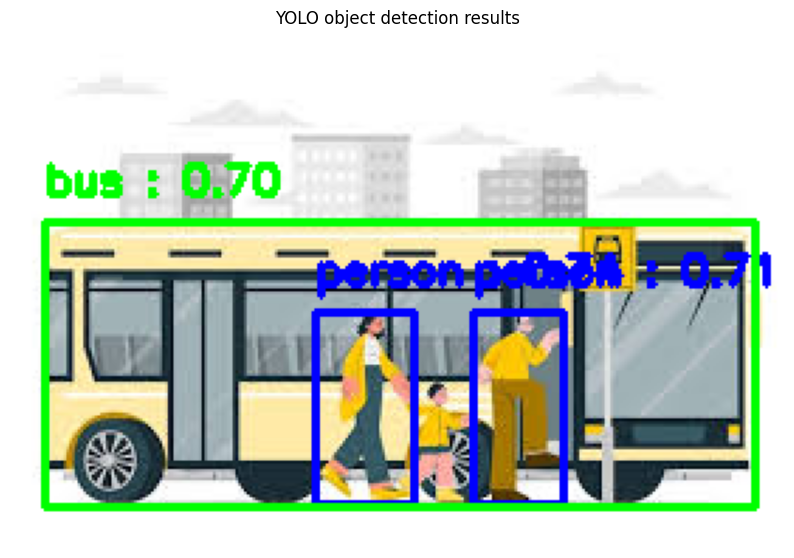

[('person', 0.7390809655189514, (108, 99, 143, 167)), ('person', 0.7142395377159119, (164, 99, 196, 167)), ('bus', 0.7027866840362549, (12, 67, 264, 168))]


In [19]:
# YOLO11 나노 버전 : YOLO11n.pt 모델을 사용하여 객체 감지 수행
# 나노 버전 : 작은 모델로 빠른 속도와 낮은 연산량을 제공하지만, 정확도가 다소 낮을 수 있습니다. 실시간 감지나 리소스가 제한된 환경에서 유용합니다.
model = YOLO('yolo11n.pt')

# 감지할 이미지
image_path = 'test.jpeg'  # 감지할 이미지 경로
image = cv2.imread(image_path)

# 이미지가 제대로 불러와졌는지 확인
if image is None:
    print("이미지를 불러올 수 없습니다. 경로를 확인해주세요.")
    exit()

# 이미지 객체 감지 수행
results = model(image)

# 감지된 객체 정보를 저장할 리스트
detected_objects = []

# 감지된 객체 정보 추출
for result in results:
    for box in result.boxes:
        # 클래스 ID
        label_id = int(box.cls[0])

        # 클래스 이름
        label = result.names[label_id]

        # 객체의 신뢰도
        confidence = float(box.conf[0])

        # 객체의 경계 상자 좌표
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # 객체의 라벨명, 신뢰도, 좌표 저장
        detected_objects.append((label, confidence, (x1, y1, x2, y2)))

        colors = {
            "person": (255, 0, 0),
            "bus": (0, 255, 0),
            "car": (0, 0, 255),
            "truck": (255, 255, 0),
            "dog": (255, 0, 255),
            "cat": (0, 255, 255),
            "motorcycle": (128, 128, 255),
            "bird": (128, 255, 128),
        }

        color = colors.get(label, (255, 255, 255))

        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

        cv2.putText(
            image,
            f"{label} : {confidence:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )
        
# 결과 이미지 파일로 저장(시간대별)
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_image_path = f"detected_{timestamp}.jpg"
cv2.imwrite(output_image_path, image)
print(f"감지된 객체가 포함된 이미지가 '{output_image_path}'로 저장되었습니다.")

# 감지된 객체에 대한 설명과 링크 출력
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("YOLO object detection results")
plt.show()

print(detected_objects)


In [21]:
'''
YOLO 이론 설명
Detection  :  객체 감지란 이미지나 비디오에서 특정 객체를 식별하고 위치를 찾는 기술입니다.
            YOLO(You Only Look Once)는 객체 감지 알고리즘 중 하나로, 이미지 전체를 한 번에 처리하여 빠른 속도로 객체를 감지할 수 있습니다.
            YOLO는 이미지 분할과 분류를 동시에 수행하여 높은 정확도와 실시간 성능을 제공합니다.
            YOLO는 다양한 버전이 있으며, 각 버전은 모델 크기와 정확도 사이의 균형을 맞추기 위해 설계되었습니다.

Trajectory : Trajectory는 객체의 이동 경로를 추적하는 기술입니다.
            YOLO와 같은 객체 감지 알고리즘과 결합하여, 감지된 객체의 위치를 시간에 따라 추적할 수 있습니다.
            이를 통해 객체의 이동 패턴을 분석하거나, 특정 객체가 특정 영역을 통과하는지 여부를 확인할 수 있습니다.
            Trajectory는 보안 감시, 스포츠 분석, 자율 주행 차량 등 다양한 분야에서 활용됩니다.
'''


# 감지된 객체에 대한 설명 + 링크
description_test = ""

# 감지된 객체 이름만 추출
detected_labels = [obj[0] for obj in detected_objects]


# 중복 제거
for label in set(detected_labels):
    if label in object_info:
        description_test += f"\n[{label} 감지됨]\n"
        description_test += f"설명       : {object_info[label]['description']}\n"
        description_test += f"사용 사례   : {object_info[label]['use_case']}\n"
        description_test += f"자세한 정보 : {object_info[label]['link']}\n"
        description_test += "-----------------------------------\n"
    else:
        description_test += f"\n[{label} 감지됨]\n"
        description_test += "설명       : 등록된 설명 정보가 없습니다.\n"
        description_test += "-----------------------------------\n"

print("객체 설명 : ", description_test)

log_file = 'yolo4_description.csv'
with open(log_file, mode='a', newline='', encoding='utf-8') as log:
    log.write(f"{timestamp}, {description_test}\n")

print(f"객체 설명이 '{log_file}' 파일에 저장되었습니다.")

객체 설명 :  
[bus 감지됨]
설명       : 이 객체는 버스가 감지된 경우입니다. 버스 감지는 대중교통 분석, 버스 전용차로 감시 및 혼잡도 모니터링 등에 활용됩니다.
사용 사례   : 버스 감지는 스마트 시티 교통 시스템, 버스 정류장 혼잡도 분석 및 통근 시간 최적화에 사용됩니다.
자세한 정보 : https://ko.wikipedia.org/wiki/%EB%B2%84%EC%8A%A4
-----------------------------------

[person 감지됨]
설명       : 이 객체는 사람이 감지된 경우입니다. 사람 감지는 보안 감시, 출입 관리 시스템 등에 매우 유용합니다. 또한 얼굴 인식, 행동 분석 등 다양한 분야에 적용됩니다.
사용 사례   : 사람 감지는 보안 시스템에서 출입 관리, 비상 상황에서의 대처, 헬스케어 분야에서 노인 및 환자의 상태 모니터링에 사용됩니다.
자세한 정보 : https://ko.wikipedia.org/wiki/%EC%82%AC%EB%9E%8C
-----------------------------------

객체 설명이 'yolo4_description.csv' 파일에 저장되었습니다.


객체 갯수 : 
person: 2개
bus: 1개
객체 갯수가 'yolo4_object_count.csv' 파일에 저장되었습니다.
위험 객체 감지 : bus


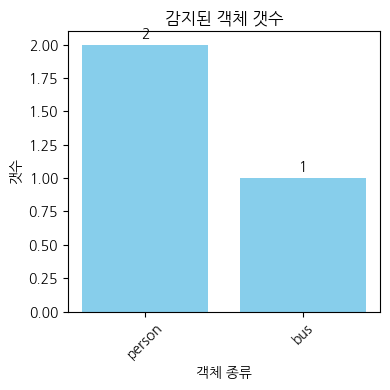

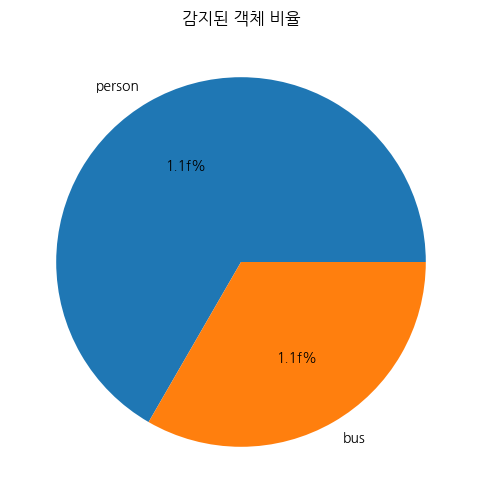

In [46]:
# 객체 갯수 세기
object_count = Counter(label for label, _, _ in detected_objects)           # _는 튜플에서 사용하지 않는 좌표 값을 무시하기 위한 플레이스홀더입니다.
print("객체 갯수 : ")
for label, count in object_count.items():
    print(f"{label}: {count}개")

# 객체 등장 시간 CSV로 저장
csv_file = 'yolo4_object_count.csv'
with open(csv_file, mode='a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)

    for label, count in object_count.items():
        writer.writerow([timestamp, label, count])

print(f"객체 갯수가 '{csv_file}' 파일에 저장되었습니다.")

# 특정 객체 위험 감지
danger_obj = ["knife", "fire", "bus"]
for label, confidence, _ in detected_objects:                               # _는 좌표 값을 사용하지 않으므로 플레이스홀더로 사용합니다.
    if label in danger_obj:
        print(f"위험 객체 감지 : {label}")



# 객체 갯수 막대그래프로 plot
#별도의 한글폰트 설정이 필요 없는 라이브러리 
import koreanize_matplotlib  

labels = list(object_count.keys())
counts = list(object_count.values())
plt.figure(figsize=(4, 4))

# 막대그래프 그리기
bars = plt.bar(labels, counts, color='skyblue')
# 막대 위에 갯수 표시
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.05, f'{b.get_height()}', ha='center')

plt.xlabel('객체 종류')
plt.ylabel('갯수')
plt.title('감지된 객체 갯수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Piechart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct="1.1f%%")
plt.title("감지된 객체 비율")
plt.show()